### **Подключение модулей**

In [1]:
from system_check import *
CUDA_state_print()

CUDA доступна: True
Количество GPU: 2

GPU #0:
Название: NVIDIA GeForce RTX 5090
Вычислительная способность (CUDA Capability): (12, 0)
Объем памяти: 31.36 GB

GPU #1:
Название: NVIDIA GeForce RTX 5090
Вычислительная способность (CUDA Capability): (12, 0)
Объем памяти: 31.36 GB


In [2]:
import sys
sys.path.append("/global_functions")
from global_functions.global_functions import *

------------------------------------
---> Choosing resource
---> Result of torch.cuda.is_available():
True
---> Final resource
-----> CUDA: 1
-----> device: cuda:1
------------------------------------


/home/pmartynyuk/UnTIE project/untie_venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
loading file vocab.txt
loading file added_tokens.json
loading file special_tokens_map.json
loading file tokenizer_config.json
loading file tokenizer.json
loading file chat_template.jinja
loading configuration file /home/pmartynyuk/UnTIE project/scripts/models_processing/models/eng_sentence_transformer_model/config.json
Model config BertConfig {
  "architectures": [
    "BertModel"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 1024,
  "initializer_range": 0.02,
  "intermediate_size": 4096,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_atte

In [3]:
datasets_results_path = "../datasets_results"
res_name = "results_1.json"

df_res1 = load_dataframe_from_json(f"{datasets_results_path}/{res_name}")

#pd.set_option('display.max_rows', None)  # Показать все строки
#pd.set_option('display.max_columns', None)  # Показать все колонки
#display(df_res1)
df_res1.head()

,doc_id,original_text,tasks,tasks_cleaned,first_answer,corrected_answer,keywords,metrics
0,000f90380d768a85e2316225854fc377c079b5c4,Full - Resolution Residual Networks for Semant...,"[Semantic_Segmentation, Real-Time_Semantic_Seg...","[Semantic Segmentation, Real-Time Semantic Seg...",To improve segmentation performance at object ...,Semantic image segmentation,"['score', 'accuracy', 'pretraine', 'geometry']","{'cosine_sim': 0.9270111322402954, 'lev_dist': 7}"
1,0012de6bec1f25599e4f02517637e531a71909b9,document: V - Net: Fully Convolutional Neural ...,[Volumetric_Medical_Image_Segmentation],[Volumetric Medical Image Segmentation],"classification, segmentation and object detect...",--None--,--None--,"{'cosine_sim': 0.5885287523269653, 'lev_dist':..."
2,007ab5528b3bd310a80d553cccad4b78dc496b02,document: Bi - Directional Attention Flow for ...,"[Question_Answering, Open-Domain_Question_Answ...","[Question Answering, Open-Domain Question Answ...",answering the query.,question answering,"['enable', 'improvement', 'year', 'allow', 'na...","{'cosine_sim': 0.9999996423721313, 'lev_dist': 2}"
3,0095c269e7d0c990249312687fc43521019809c4,document: Modelling Interaction of Sentence Pa...,[Natural_Language_Inference],[Natural Language Inference],determine the semantic relationship between tw...,--None--,--None--,"{'cosine_sim': 0.6914587616920471, 'lev_dist':..."
4,00b1cdc5bd77bf27f9b1ca630365eeeb456913b4,document: Mastering Chess and Shogi by Self - ...,"[Game_of_Go, Game_of_Shogi]","[Game of Go, Game of Shogi]",search is focused on promising variations,--None--,--None--,"{'cosine_sim': 0.5607925653457642, 'lev_dist':..."


In [4]:
# Фильтруем строки, где corrected_answer не равно "--None--"
filtered_df = df_res1[df_res1['corrected_answer'] != '--None--']

In [5]:
len(filtered_df)

244

In [6]:
len(filtered_df)/len(df_res1) * 100

79.73856209150327

In [7]:
import matplotlib.pyplot as plt
import ast

# Извлекаем метрики напрямую
cosine_sim_values = [ast.literal_eval(metric)['cosine_sim'] for metric in filtered_df['metrics'] if isinstance(metric, str)]
lev_dist_values = [ast.literal_eval(metric)['lev_dist'] for metric in filtered_df['metrics'] if isinstance(metric, str)]

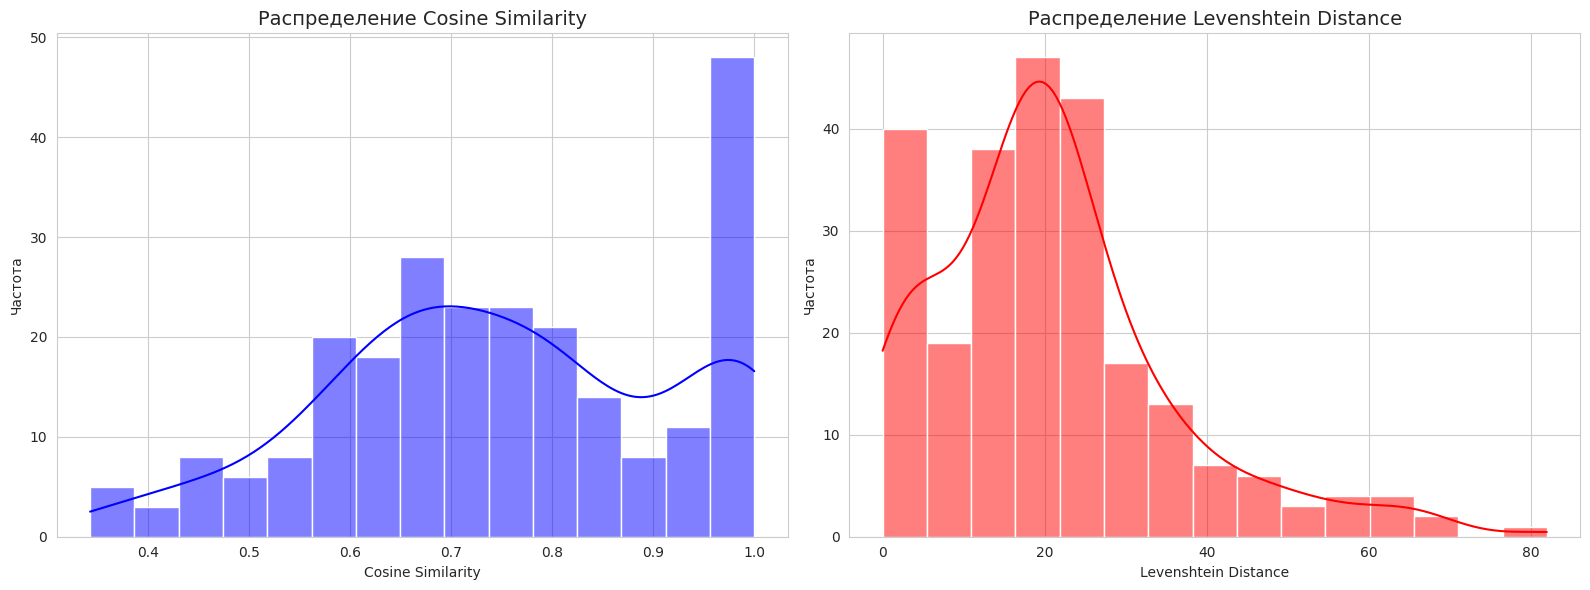

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Настройка стиля
sns.set_style("whitegrid")
plt.figure(figsize=(16, 6))

# Cosine similarity
plt.subplot(1, 2, 1)
sns.histplot(cosine_sim_values, bins=15, kde=True, color='blue')
plt.title('Распределение Cosine Similarity', fontsize=14)
plt.xlabel('Cosine Similarity')
plt.ylabel('Частота')

# Levenshtein distance
plt.subplot(1, 2, 2)
sns.histplot(lev_dist_values, bins=15, kde=True, color='red')
plt.title('Распределение Levenshtein Distance', fontsize=14)
plt.xlabel('Levenshtein Distance')
plt.ylabel('Частота')

plt.tight_layout()
plt.show()

In [9]:
res2_name = "results_2.json"

df_res2 = load_dataframe_from_json(f"{datasets_results_path}/{res2_name}")

#pd.set_option('display.max_rows', None)  # Показать все строки
#pd.set_option('display.max_columns', None)  # Показать все колонки
#display(df_res1)
df_res2.head()

,doc_id,original_text,tasks,tasks_cleaned,first_answer,corrected_answer,keywords,metrics_orig,metrics_new
0,000f90380d768a85e2316225854fc377c079b5c4,Full - Resolution Residual Networks for Semant...,"[Semantic_Segmentation, Real-Time_Semantic_Seg...","[Semantic Segmentation, Real-Time Semantic Seg...",To improve segmentation performance at object ...,Semantic image segmentation,"['score', 'accuracy', 'pretraine', 'geometry']","{'cosine_sim': 0.6268187761306763, 'lev_dist':...","{'cosine_sim': 0.9270111322402954, 'lev_dist': 7}"
1,0012de6bec1f25599e4f02517637e531a71909b9,document: V - Net: Fully Convolutional Neural ...,[Volumetric_Medical_Image_Segmentation],[Volumetric Medical Image Segmentation],"classification, segmentation and object detect...",--None--,--None--,"{'cosine_sim': 0.5885287523269653, 'lev_dist':...","{'cosine_sim': 0.5885287523269653, 'lev_dist':..."
2,007ab5528b3bd310a80d553cccad4b78dc496b02,document: Bi - Directional Attention Flow for ...,"[Question_Answering, Open-Domain_Question_Answ...","[Question Answering, Open-Domain Question Answ...",answering the query.,question answering,"['enable', 'improvement', 'year', 'allow', 'na...","{'cosine_sim': 0.8998040556907654, 'lev_dist':...","{'cosine_sim': 0.9999996423721313, 'lev_dist': 2}"
3,0095c269e7d0c990249312687fc43521019809c4,document: Modelling Interaction of Sentence Pa...,[Natural_Language_Inference],[Natural Language Inference],determine the semantic relationship between tw...,--None--,--None--,"{'cosine_sim': 0.6914587616920471, 'lev_dist':...","{'cosine_sim': 0.6914587616920471, 'lev_dist':..."
4,00b1cdc5bd77bf27f9b1ca630365eeeb456913b4,document: Mastering Chess and Shogi by Self - ...,"[Game_of_Go, Game_of_Shogi]","[Game of Go, Game of Shogi]",search is focused on promising variations,--None--,--None--,"{'cosine_sim': 0.5607925653457642, 'lev_dist':...","{'cosine_sim': 0.5607925653457642, 'lev_dist':..."


In [10]:
# Фильтруем строки, где corrected_answer не равно "--None--"
filtered2_df = df_res2[df_res2['corrected_answer'] != '--None--']
len(filtered2_df)

244

In [11]:
filtered2_df.head()

,doc_id,original_text,tasks,tasks_cleaned,first_answer,corrected_answer,keywords,metrics_orig,metrics_new
0,000f90380d768a85e2316225854fc377c079b5c4,Full - Resolution Residual Networks for Semant...,"[Semantic_Segmentation, Real-Time_Semantic_Seg...","[Semantic Segmentation, Real-Time Semantic Seg...",To improve segmentation performance at object ...,Semantic image segmentation,"['score', 'accuracy', 'pretraine', 'geometry']","{'cosine_sim': 0.6268187761306763, 'lev_dist':...","{'cosine_sim': 0.9270111322402954, 'lev_dist': 7}"
2,007ab5528b3bd310a80d553cccad4b78dc496b02,document: Bi - Directional Attention Flow for ...,"[Question_Answering, Open-Domain_Question_Answ...","[Question Answering, Open-Domain Question Answ...",answering the query.,question answering,"['enable', 'improvement', 'year', 'allow', 'na...","{'cosine_sim': 0.8998040556907654, 'lev_dist':...","{'cosine_sim': 0.9999996423721313, 'lev_dist': 2}"
5,01125e3c68edb420b8d884ff53fb38d9fbe4f2b8,document: Large Pose 3D Face Reconstruction fr...,[3D_Face_Reconstruction],[3D Face Reconstruction],3D facial landmark localisation,3D facial landmark localisation,"['training', 'novel', 'architecture', 'assumpt...","{'cosine_sim': 0.9436883926391602, 'lev_dist':...","{'cosine_sim': 0.9436883926391602, 'lev_dist':..."
6,0116899fce00ffa4afee08b505300bb3968faf9f,Long Text Generation via Adversarial Training ...,[Text_Generation],[Text Generation],the next word to select,the next word to select,"['game', 'training', 'discriminator']","{'cosine_sim': 0.6716794371604919, 'lev_dist':...","{'cosine_sim': 0.6716794371604919, 'lev_dist':..."
7,0171bdeb1c6e333287be655c667cfba5edb89b76,Aggregated Residual Transformations for Deep N...,[Image_Classification],[Image Classification],factors.,Object Detection,"['reduce', 'average', 'recently']","{'cosine_sim': 0.6920448541641235, 'lev_dist':...","{'cosine_sim': 0.8140521049499512, 'lev_dist':..."


In [12]:
len(filtered2_df)/len(df_res2) * 100

79.73856209150327

In [13]:
import ast
import pandas as pd
import warnings

# Подавляем предупреждения SettingWithCopyWarning (опционально)
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)

def parse_metrics_string(metric_str):
    """
    Парсит строку с метриками в словарь
    """
    try:
        # Пытаемся преобразовать строку в словарь
        if isinstance(metric_str, str):
            return ast.literal_eval(metric_str)
        elif isinstance(metric_str, dict):
            return metric_str
        else:
            return {}
    except (ValueError, SyntaxError):
        # В случае ошибки парсинга возвращаем пустой словарь
        return {}

# Создаем копию DataFrame, чтобы избежать предупреждений
filtered2_df_working = filtered2_df.copy()

# Преобразуем строки в словари
filtered2_df_working['metrics_orig_parsed'] = filtered2_df_working['metrics_orig'].apply(parse_metrics_string)
filtered2_df_working['metrics_new_parsed'] = filtered2_df_working['metrics_new'].apply(parse_metrics_string)

# Создаем маски для условий улучшения по каждой метрике
cosine_improved = filtered2_df_working.apply(
    lambda row: row['metrics_new_parsed'].get('cosine_sim', 0) > row['metrics_orig_parsed'].get('cosine_sim', 0), 
    axis=1
)

levenshtein_improved = filtered2_df_working.apply(
    lambda row: row['metrics_new_parsed'].get('lev_dist', float('inf')) < row['metrics_orig_parsed'].get('lev_dist', float('inf')), 
    axis=1
)

# Подсчитываем количество улучшений
cosine_improved_count = cosine_improved.sum()
levenshtein_improved_count = levenshtein_improved.sum()

# Вычисляем общее количество строк
total_rows = len(filtered2_df_working)

# Рассчитываем процент улучшений
cosine_improved_percentage = (cosine_improved_count / total_rows) * 100 if total_rows > 0 else 0
levenshtein_improved_percentage = (levenshtein_improved_count / total_rows) * 100 if total_rows > 0 else 0

# Формируем результат
result = {
    'cosine_sim': {
        'improved_count': cosine_improved_count,
        'improved_percentage': round(cosine_improved_percentage, 2),
        'total_rows': total_rows
    },
    'lev_dist': {
        'improved_count': levenshtein_improved_count,
        'improved_percentage': round(levenshtein_improved_percentage, 2),
        'total_rows': total_rows
    }
}

print(f"Анализ улучшений:")
print(f"Косинусное сходство: улучшено в {result['cosine_sim']['improved_count']} из {result['cosine_sim']['total_rows']} строк ({result['cosine_sim']['improved_percentage']}%)")
print(f"Расстояние Левенштейна: улучшено в {result['lev_dist']['improved_count']} из {result['lev_dist']['total_rows']} строк ({result['lev_dist']['improved_percentage']}%)")

# Дополнительно: посмотрим на строки, которые не удалось распарсить
failed_to_parse = filtered2_df_working[
    (filtered2_df_working['metrics_orig_parsed'] == {}) | 
    (filtered2_df_working['metrics_new_parsed'] == {})
]

if len(failed_to_parse) > 0:
    print(f"\nВнимание: не удалось распарсить {len(failed_to_parse)} строк")
    print("Пример проблемных строк:")
    print(failed_to_parse[['metrics_orig', 'metrics_new']].head())

Анализ улучшений:
Косинусное сходство: улучшено в 91 из 244 строк (37.3%)
Расстояние Левенштейна: улучшено в 86 из 244 строк (35.25%)


In [14]:
# Анализ для cosine_sim
cosine_comparison = filtered2_df_working.apply(
    lambda row: (
        'improved' if row['metrics_new_parsed'].get('cosine_sim', 0) > row['metrics_orig_parsed'].get('cosine_sim', 0) else
        'worsened' if row['metrics_new_parsed'].get('cosine_sim', 0) < row['metrics_orig_parsed'].get('cosine_sim', 0) else
        'unchanged'
    ), 
    axis=1
)

cosine_counts = cosine_comparison.value_counts()
cosine_percentages = (cosine_counts / len(filtered2_df_working)) * 100

print("Анализ изменений cosine_sim:")
for status in ['improved', 'unchanged', 'worsened']:
    count = cosine_counts.get(status, 0)
    percentage = cosine_percentages.get(status, 0)
    print(f"{status}: {count} строк ({percentage:.2f}%)")

print("\n" + "="*50 + "\n")

# Анализ для lev_dist
levenshtein_comparison = filtered2_df_working.apply(
    lambda row: (
        'improved' if row['metrics_new_parsed'].get('lev_dist', float('inf')) < row['metrics_orig_parsed'].get('lev_dist', float('inf')) else
        'worsened' if row['metrics_new_parsed'].get('lev_dist', float('inf')) > row['metrics_orig_parsed'].get('lev_dist', float('inf')) else
        'unchanged'
    ), 
    axis=1
)

levenshtein_counts = levenshtein_comparison.value_counts()
levenshtein_percentages = (levenshtein_counts / len(filtered2_df_working)) * 100

print("Анализ изменений lev_dist:")
for status in ['improved', 'unchanged', 'worsened']:
    count = levenshtein_counts.get(status, 0)
    percentage = levenshtein_percentages.get(status, 0)
    print(f"{status}: {count} строк ({percentage:.2f}%)")

Анализ изменений cosine_sim:
improved: 91 строк (37.30%)
unchanged: 84 строк (34.43%)
worsened: 69 строк (28.28%)


Анализ изменений lev_dist:
improved: 86 строк (35.25%)
unchanged: 91 строк (37.30%)
worsened: 67 строк (27.46%)


СТАТИСТИКА ДЛЯ COSINE_SIM:
Улучшения (n=91):
  Среднее: 0.1478
  Медиана: 0.1159
  Стандартное отклонение: 0.1144
  Минимум: 0.0028
  Максимум: 0.5133

Ухудшения (n=69):
  Среднее: -0.1258
  Медиана: -0.0896
  Стандартное отклонение: 0.1140
  Минимум: -0.4474
  Максимум: -0.0003


СТАТИСТИКА ДЛЯ LEV_DIST:
Улучшения (n=86):
  Среднее: 11.26
  Медиана: 7.50
  Стандартное отклонение: 11.03
  Минимум: 1.00
  Максимум: 58.00

Ухудшения (n=67):
  Среднее: -14.99
  Медиана: -12.00
  Стандартное отклонение: 12.99
  Минимум: -54.00
  Максимум: -1.00


/tmp/ipykernel_1387498/2549284935.py:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot([cosine_improved, cosine_worsened], labels=['Улучшения', 'Ухудшения'])
/tmp/ipykernel_1387498/2549284935.py:100: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot([levenshtein_improved, levenshtein_worsened], labels=['Улучшения', 'Ухудшения'])


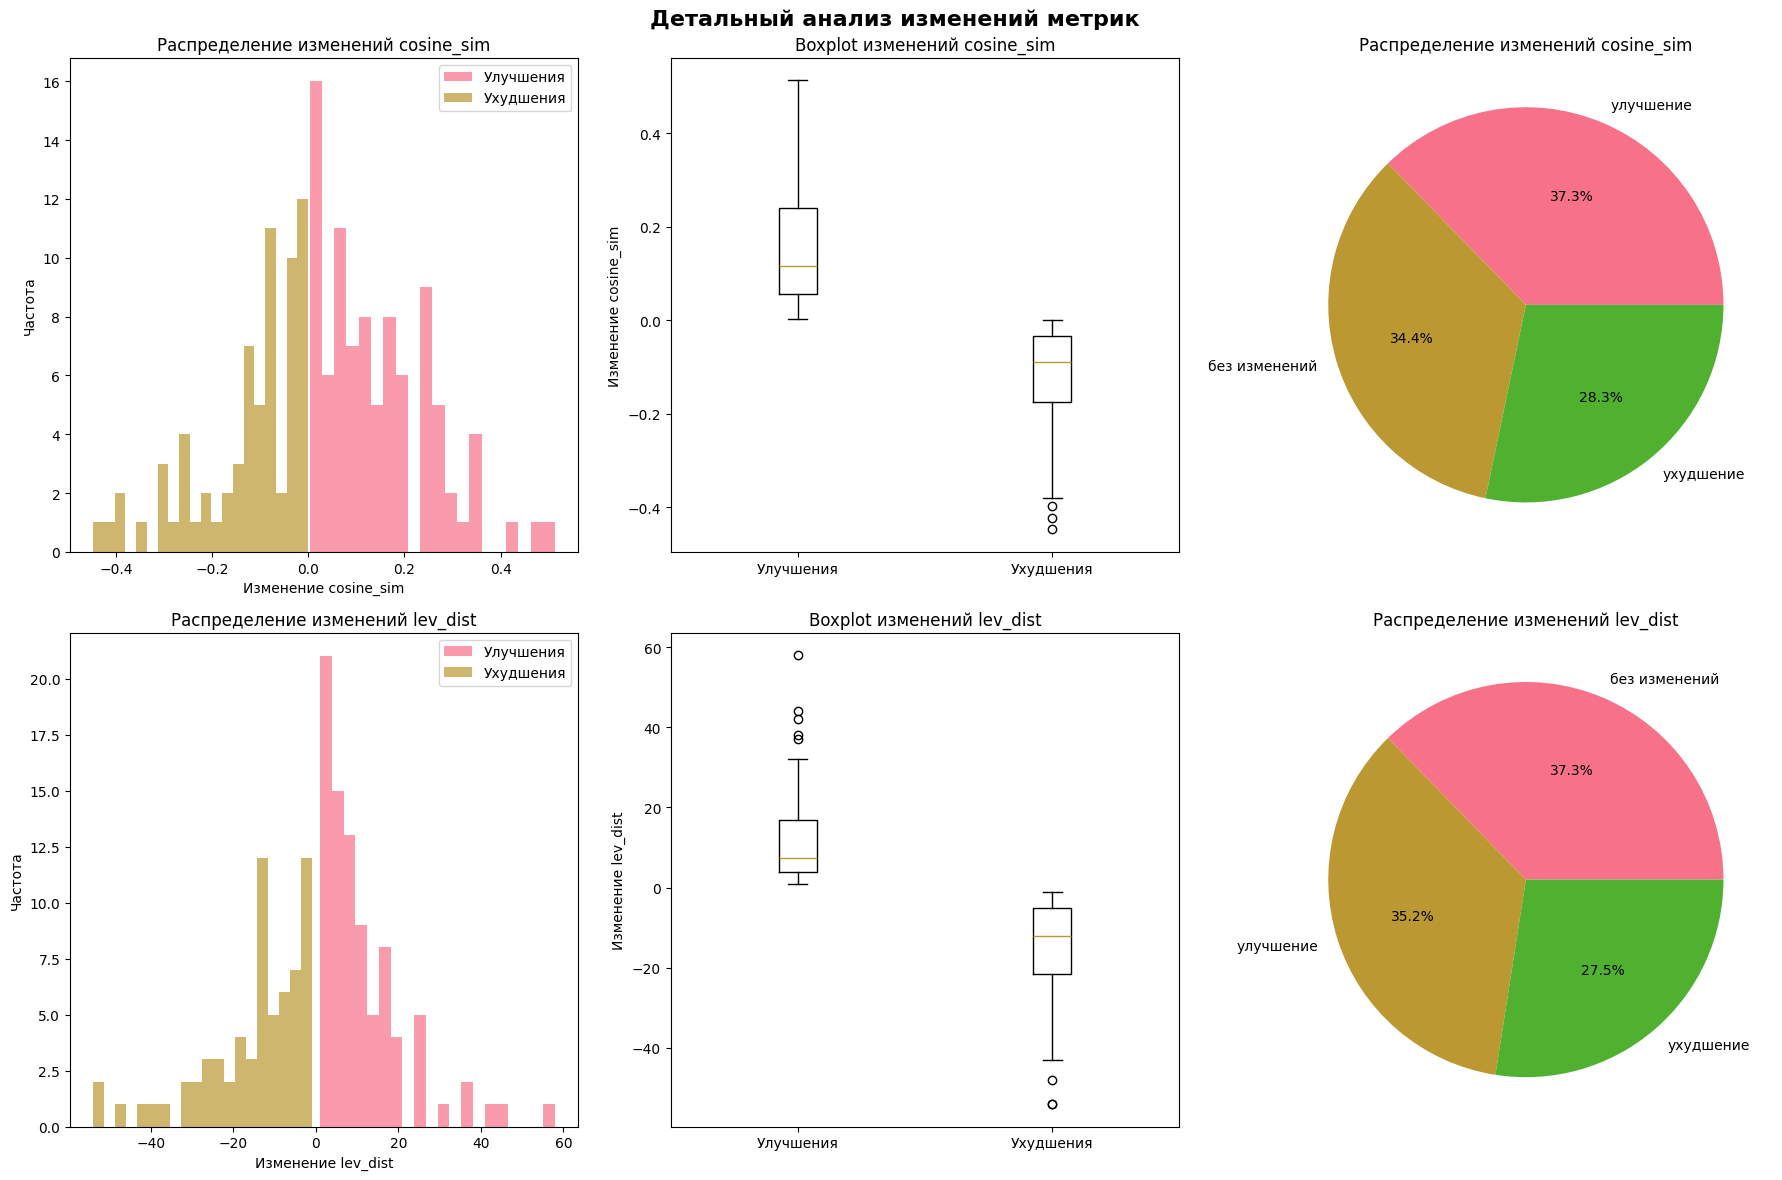



СТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ РАЗЛИЧИЙ:
Cosine sim: t-статистика = 15.0071, p-значение = 0.0000
  Различия статистически значимы (p < 0.05)
Lev dist: t-статистика = 13.2330, p-значение = 0.0000
  Различия статистически значимы (p < 0.05)


АНАЛИЗ ЭКСТРЕМАЛЬНЫХ ИЗМЕНЕНИЙ:
Cosine sim - наибольшие улучшения:
  1. Строка 11: 0.5133
  2. Строка 115: 0.4762
  3. Строка 219: 0.4255
  4. Строка 123: 0.3575
  5. Строка 161: 0.3494

Cosine sim - наибольшие ухудшения:
  1. Строка 10: -0.4474
  2. Строка 216: -0.4239
  3. Строка 51: -0.3972
  4. Строка 228: -0.3804
  5. Строка 191: -0.3419

Lev dist - наибольшие улучшения:
  1. Строка 219: 58.00
  2. Строка 168: 44.00
  3. Строка 252: 42.00
  4. Строка 298: 38.00
  5. Строка 0: 37.00

Lev dist - наибольшие ухудшения:
  1. Строка 18: -54.00
  2. Строка 32: -54.00
  3. Строка 114: -48.00
  4. Строка 140: -43.00
  5. Строка 204: -39.00


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Настройка визуализации
plt.style.use('default')
sns.set_palette("husl")
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Детальный анализ изменений метрик', fontsize=16, fontweight='bold')

# Вычисляем разницы для каждой метрики
filtered2_df_working['cosine_diff'] = filtered2_df_working.apply(
    lambda row: row['metrics_new_parsed'].get('cosine_sim', 0) - row['metrics_orig_parsed'].get('cosine_sim', 0), 
    axis=1
)

filtered2_df_working['levenshtein_diff'] = filtered2_df_working.apply(
    lambda row: row['metrics_orig_parsed'].get('lev_dist', 0) - row['metrics_new_parsed'].get('lev_dist', 0), 
    axis=1
)

# Определяем категории изменений для каждой метрики
filtered2_df_working['cosine_change'] = pd.cut(
    filtered2_df_working['cosine_diff'], 
    bins=[-np.inf, -0.0001, 0.0001, np.inf],
    labels=['ухудшение', 'без изменений', 'улучшение']
)

filtered2_df_working['levenshtein_change'] = pd.cut(
    filtered2_df_working['levenshtein_diff'], 
    bins=[-np.inf, -0.0001, 0.0001, np.inf],
    labels=['ухудшение', 'без изменений', 'улучшение']
)

# 1. Статистика по изменениям cosine_sim
cosine_improved = filtered2_df_working[filtered2_df_working['cosine_change'] == 'улучшение']['cosine_diff']
cosine_worsened = filtered2_df_working[filtered2_df_working['cosine_change'] == 'ухудшение']['cosine_diff']

print("СТАТИСТИКА ДЛЯ COSINE_SIM:")
print(f"Улучшения (n={len(cosine_improved)}):")
print(f"  Среднее: {cosine_improved.mean():.4f}")
print(f"  Медиана: {cosine_improved.median():.4f}")
print(f"  Стандартное отклонение: {cosine_improved.std():.4f}")
print(f"  Минимум: {cosine_improved.min():.4f}")
print(f"  Максимум: {cosine_improved.max():.4f}")

print(f"\nУхудшения (n={len(cosine_worsened)}):")
print(f"  Среднее: {cosine_worsened.mean():.4f}")
print(f"  Медиана: {cosine_worsened.median():.4f}")
print(f"  Стандартное отклонение: {cosine_worsened.std():.4f}")
print(f"  Минимум: {cosine_worsened.min():.4f}")
print(f"  Максимум: {cosine_worsened.max():.4f}")

# Визуализация для cosine_sim
axes[0, 0].hist(cosine_improved, bins=20, alpha=0.7, label='Улучшения')
axes[0, 0].hist(cosine_worsened, bins=20, alpha=0.7, label='Ухудшения')
axes[0, 0].set_title('Распределение изменений cosine_sim')
axes[0, 0].set_xlabel('Изменение cosine_sim')
axes[0, 0].set_ylabel('Частота')
axes[0, 0].legend()

axes[0, 1].boxplot([cosine_improved, cosine_worsened], labels=['Улучшения', 'Ухудшения'])
axes[0, 1].set_title('Boxplot изменений cosine_sim')
axes[0, 1].set_ylabel('Изменение cosine_sim')

# Круговая диаграмма для cosine_sim
cosine_counts = filtered2_df_working['cosine_change'].value_counts()
axes[0, 2].pie(cosine_counts.values, labels=cosine_counts.index, autopct='%1.1f%%')
axes[0, 2].set_title('Распределение изменений cosine_sim')

# 2. Статистика по изменениям lev_dist
levenshtein_improved = filtered2_df_working[filtered2_df_working['levenshtein_change'] == 'улучшение']['levenshtein_diff']
levenshtein_worsened = filtered2_df_working[filtered2_df_working['levenshtein_change'] == 'ухудшение']['levenshtein_diff']

print("\n\nСТАТИСТИКА ДЛЯ LEV_DIST:")
print(f"Улучшения (n={len(levenshtein_improved)}):")
print(f"  Среднее: {levenshtein_improved.mean():.2f}")
print(f"  Медиана: {levenshtein_improved.median():.2f}")
print(f"  Стандартное отклонение: {levenshtein_improved.std():.2f}")
print(f"  Минимум: {levenshtein_improved.min():.2f}")
print(f"  Максимум: {levenshtein_improved.max():.2f}")

print(f"\nУхудшения (n={len(levenshtein_worsened)}):")
print(f"  Среднее: {levenshtein_worsened.mean():.2f}")
print(f"  Медиана: {levenshtein_worsened.median():.2f}")
print(f"  Стандартное отклонение: {levenshtein_worsened.std():.2f}")
print(f"  Минимум: {levenshtein_worsened.min():.2f}")
print(f"  Максимум: {levenshtein_worsened.max():.2f}")

# Визуализация для lev_dist
axes[1, 0].hist(levenshtein_improved, bins=20, alpha=0.7, label='Улучшения')
axes[1, 0].hist(levenshtein_worsened, bins=20, alpha=0.7, label='Ухудшения')
axes[1, 0].set_title('Распределение изменений lev_dist')
axes[1, 0].set_xlabel('Изменение lev_dist')
axes[1, 0].set_ylabel('Частота')
axes[1, 0].legend()

axes[1, 1].boxplot([levenshtein_improved, levenshtein_worsened], labels=['Улучшения', 'Ухудшения'])
axes[1, 1].set_title('Boxplot изменений lev_dist')
axes[1, 1].set_ylabel('Изменение lev_dist')

# Круговая диаграмма для lev_dist
levenshtein_counts = filtered2_df_working['levenshtein_change'].value_counts()
axes[1, 2].pie(levenshtein_counts.values, labels=levenshtein_counts.index, autopct='%1.1f%%')
axes[1, 2].set_title('Распределение изменений lev_dist')

plt.tight_layout()
plt.show()

# 3. Дополнительный анализ: проверка на статистическую значимость
print("\n\nСТАТИСТИЧЕСКАЯ ЗНАЧИМОСТЬ РАЗЛИЧИЙ:")
# Для cosine_sim: сравниваем улучшения и ухудшения
if len(cosine_improved) > 1 and len(cosine_worsened) > 1:
    t_stat, p_value = stats.ttest_ind(cosine_improved, cosine_worsened, equal_var=False)
    print(f"Cosine sim: t-статистика = {t_stat:.4f}, p-значение = {p_value:.4f}")
    if p_value < 0.05:
        print("  Различия статистически значимы (p < 0.05)")
    else:
        print("  Различия не статистически значимы (p >= 0.05)")

# Для lev_dist: сравниваем улучшения и ухудшения
if len(levenshtein_improved) > 1 and len(levenshtein_worsened) > 1:
    t_stat, p_value = stats.ttest_ind(levenshtein_improved, levenshtein_worsened, equal_var=False)
    print(f"Lev dist: t-статистика = {t_stat:.4f}, p-значение = {p_value:.4f}")
    if p_value < 0.05:
        print("  Различия статистически значимы (p < 0.05)")
    else:
        print("  Различия не статистически значимы (p >= 0.05)")

# 4. Анализ экстремальных изменений
print("\n\nАНАЛИЗ ЭКСТРЕМАЛЬНЫХ ИЗМЕНЕНИЙ:")
# Для cosine_sim
cosine_extreme_improvement = cosine_improved.nlargest(5)
cosine_extreme_worsening = cosine_worsened.nsmallest(5)

print("Cosine sim - наибольшие улучшения:")
for i, (idx, val) in enumerate(cosine_extreme_improvement.items(), 1):
    print(f"  {i}. Строка {idx}: {val:.4f}")

print("\nCosine sim - наибольшие ухудшения:")
for i, (idx, val) in enumerate(cosine_extreme_worsening.items(), 1):
    print(f"  {i}. Строка {idx}: {val:.4f}")

# Для lev_dist
levenshtein_extreme_improvement = levenshtein_improved.nlargest(5)
levenshtein_extreme_worsening = levenshtein_worsened.nsmallest(5)

print("\nLev dist - наибольшие улучшения:")
for i, (idx, val) in enumerate(levenshtein_extreme_improvement.items(), 1):
    print(f"  {i}. Строка {idx}: {val:.2f}")

print("\nLev dist - наибольшие ухудшения:")
for i, (idx, val) in enumerate(levenshtein_extreme_worsening.items(), 1):
    print(f"  {i}. Строка {idx}: {val:.2f}")

In [16]:
# Создаем условия для ухудшений по каждой метрике
worsened_cosine = filtered2_df_working['metrics_new_parsed'].apply(
    lambda x: x.get('cosine_sim', 0)
) < filtered2_df_working['metrics_orig_parsed'].apply(
    lambda x: x.get('cosine_sim', 0)
)

worsened_levenshtein = filtered2_df_working['metrics_new_parsed'].apply(
    lambda x: x.get('lev_dist', float('inf'))
) > filtered2_df_working['metrics_orig_parsed'].apply(
    lambda x: x.get('lev_dist', float('inf'))
)

# Объединяем условия - ухудшение хотя бы по одной метрике
worsened_any = worsened_cosine | worsened_levenshtein

# Создаем датафрейм с ухудшениями
worsened_df = filtered2_df_working[worsened_any].copy()

# Добавляем информацию о том, по каким метрикам произошло ухудшение
worsened_df['worsened_cosine'] = worsened_cosine[worsened_any]
worsened_df['worsened_levenshtein'] = worsened_levenshtein[worsened_any]
worsened_df['worsened_both'] = worsened_cosine[worsened_any] & worsened_levenshtein[worsened_any]

# Добавляем количественные показатели изменений
worsened_df['cosine_diff'] = worsened_df['metrics_new_parsed'].apply(
    lambda x: x.get('cosine_sim', 0)
) - worsened_df['metrics_orig_parsed'].apply(
    lambda x: x.get('cosine_sim', 0)
)

worsened_df['levenshtein_diff'] = worsened_df['metrics_orig_parsed'].apply(
    lambda x: x.get('lev_dist', 0)
) - worsened_df['metrics_new_parsed'].apply(
    lambda x: x.get('lev_dist', 0)
)

# Анализ результатов
print(f"Всего строк с ухудшениями: {len(worsened_df)}")
print(f"Ухудшение только по cosine_sim: {worsened_df['worsened_cosine'].sum() - worsened_df['worsened_both'].sum()}")
print(f"Ухудшение только по lev_dist: {worsened_df['worsened_levenshtein'].sum() - worsened_df['worsened_both'].sum()}")
print(f"Ухудшение по обеим метрикам: {worsened_df['worsened_both'].sum()}")

# Выводим несколько примеров для ознакомления
print("\nПримеры строк с ухудшениями:")
print(worsened_df[['metrics_orig', 'metrics_new', 'worsened_cosine', 'worsened_levenshtein', 
                   'cosine_diff', 'levenshtein_diff']].head(10))

# Сохраняем в файл для дальнейшего анализа (опционально)
worsened_df.to_csv('worsened_cases.csv', index=False)
print(f"\nДатафрейм с ухудшениями сохранен в worsened_cases.csv")

# Дополнительный анализ: насколько сильно ухудшились показатели
if len(worsened_df) > 0:
    print("\nАНАЛИЗ ВЕЛИЧИНЫ УХУДШЕНИЙ:")
    print("По cosine_sim (чем отрицательнее, тем хуже):")
    print(f"  Среднее ухудшение: {worsened_df['cosine_diff'].mean():.4f}")
    print(f"  Максимальное ухудшение: {worsened_df['cosine_diff'].min():.4f}")
    print(f"  Минимальное ухудшение: {worsened_df['cosine_diff'].max():.4f}")
    
    print("\nПо lev_dist (чем отрицательнее, тем хуже):")
    print(f"  Среднее ухудшение: {worsened_df['levenshtein_diff'].mean():.2f}")
    print(f"  Максимальное ухудшение: {worsened_df['levenshtein_diff'].min():.2f}")
    print(f"  Минимальное ухудшение: {worsened_df['levenshtein_diff'].max():.2f}")

Всего строк с ухудшениями: 94
Ухудшение только по cosine_sim: 27
Ухудшение только по lev_dist: 25
Ухудшение по обеим метрикам: 42

Примеры строк с ухудшениями:
                                         metrics_orig  \
8   {'cosine_sim': 0.7258158922195435, 'lev_dist':...   
10                 {'cosine_sim': 1.0, 'lev_dist': 2}   
11  {'cosine_sim': 0.3944997787475586, 'lev_dist':...   
12  {'cosine_sim': 0.4084031581878662, 'lev_dist':...   
15  {'cosine_sim': 0.6165754795074463, 'lev_dist':...   
18  {'cosine_sim': 0.5961365103721619, 'lev_dist':...   
25  {'cosine_sim': 0.7951776385307312, 'lev_dist':...   
28  {'cosine_sim': 0.845115065574646, 'lev_dist': 15}   
32  {'cosine_sim': 0.9679177403450012, 'lev_dist':...   
39  {'cosine_sim': 0.6389878988265991, 'lev_dist':...   

                                          metrics_new  worsened_cosine  \
8   {'cosine_sim': 0.7172886729240417, 'lev_dist':...             True   
10  {'cosine_sim': 0.5526493787765503, 'lev_dist':...           

In [17]:
worsened_df

,doc_id,original_text,tasks,tasks_cleaned,first_answer,corrected_answer,keywords,metrics_orig,metrics_new,metrics_orig_parsed,metrics_new_parsed,cosine_diff,levenshtein_diff,cosine_change,levenshtein_change,worsened_cosine,worsened_levenshtein,worsened_both
8,01959ef569f74c286956024866c1d107099199f7,VQA: Visual Question Answering section: Abstra...,[Visual_Question_Answering],[Visual Question Answering],"multiple - choice task,",multiple - choice task.,"['entry', 'workshop', 'leaderboard', 'annual']","{'cosine_sim': 0.7258158922195435, 'lev_dist':...","{'cosine_sim': 0.7172886729240417, 'lev_dist':...","{'cosine_sim': 0.7258158922195435, 'lev_dist':...","{'cosine_sim': 0.7172886729240417, 'lev_dist':...",-0.008527,0,ухудшение,без изменений,True,False,False
10,0209389b8369aaa2a08830ac3b2036d4901ba1f1,document: DensePose: Dense Human Pose Estimati...,[Pose_Estimation],[Pose Estimation],pose estimation,dense supervision signal.,"['discriminative', 'outperform']","{'cosine_sim': 1.0, 'lev_dist': 2}","{'cosine_sim': 0.5526493787765503, 'lev_dist':...","{'cosine_sim': 1.0, 'lev_dist': 2}","{'cosine_sim': 0.5526493787765503, 'lev_dist':...",-0.447351,-17,ухудшение,ухудшение,True,True,True
11,020a9aba95bce75dca08e3c499efc9e100f1cbb6,document: Incentivizing Exploration In Reinfor...,[Atari_Games],[Atari Games],exploration.,"representing Atari frames,","['greedy', 'loss', 'test', 'reconstruct', 'dec...","{'cosine_sim': 0.3944997787475586, 'lev_dist':...","{'cosine_sim': 0.9078354239463806, 'lev_dist':...","{'cosine_sim': 0.3944997787475586, 'lev_dist':...","{'cosine_sim': 0.9078354239463806, 'lev_dist':...",0.513336,-4,улучшение,ухудшение,False,True,False
12,0217fb2a54a4f324ddf82babc6ec6692a3f6194f,InfoGAN: Interpretable Representation Learning...,"[Unsupervised_MNIST, Unsupervised_image_classi...","[Unsupervised MNIST, Unsupervised image classi...",explicitly labeling variations.,mutual information between latent codes c and ...,"['online', 'infogan']","{'cosine_sim': 0.4084031581878662, 'lev_dist':...","{'cosine_sim': 0.3423804044723511, 'lev_dist':...","{'cosine_sim': 0.4084031581878662, 'lev_dist':...","{'cosine_sim': 0.3423804044723511, 'lev_dist':...",-0.066023,-26,ухудшение,ухудшение,True,True,True
15,02a5b7a41ffa8518eb3b7cae9914a2bd2bbc886b,Fast Online Object Tracking and Segmentation: ...,[Visual_Object_Tracking],[Visual Object Tracking],"video object segmentation,","consistency between video frames,","['hour', 'exploit', 'computationally']","{'cosine_sim': 0.6165754795074463, 'lev_dist':...","{'cosine_sim': 0.6429635286331177, 'lev_dist':...","{'cosine_sim': 0.6165754795074463, 'lev_dist':...","{'cosine_sim': 0.6429635286331177, 'lev_dist':...",0.026388,-10,улучшение,ухудшение,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,44c5dec4d1295d34f052d3243d8e08f14a3c0990,document: Transformer - XL: Attentive Language...,[Language_Modelling],[Language Modelling],context fragmentation issue,context fragmentation.,"['improve', 'gain', 'increase']","{'cosine_sim': 0.6505337357521057, 'lev_dist':...","{'cosine_sim': 0.6208953261375427, 'lev_dist':...","{'cosine_sim': 0.6505337357521057, 'lev_dist':...","{'cosine_sim': 0.6208953261375427, 'lev_dist':...",-0.029638,4,ухудшение,улучшение,True,False,False
299,4543052aeaf52fdb01fced9b3ccf97827582cef5,document: Quantized Densely Connected U - Nets...,[Pose_Estimation],[Pose Estimation],Human Pose Estimation.,connect a U - Net to its successors.,"['densely', 'boost']","{'cosine_sim': 0.8685598969459534, 'lev_dist': 7}","{'cosine_sim': 0.5638068318367004, 'lev_dist':...","{'cosine_sim': 0.8685598969459534, 'lev_dist': 7}","{'cosine_sim': 0.5638068318367004, 'lev_dist':...",-0.304753,-23,ухудшение,ухудшение,True,True,True
302,45e8ef229fae18b0a2ab328037d8e520866c3c81,document: Learning Feature Pyramids for Human ...,[Pose_Estimation],[Pose Estimation],human pose estimation.,human pose estimation,['convolutional'],"{'cosine_sim': 0.8685598969459534, '